<a href="https://colab.research.google.com/github/Bruhmomentxd123/Inteligencia_Artificial/blob/main/examen_medio_curso.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Primeras 5 filas:
    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0    3504          12.0   
1  15.0          8         350.0       165.0    3693          11.5   
2  18.0          8         318.0       150.0    3436          11.0   
3  16.0          8         304.0       150.0    3433          12.0   
4  17.0          8         302.0       140.0    3449          10.5   

   model_year origin                       name  
0          70    usa  chevrolet chevelle malibu  
1          70    usa          buick skylark 320  
2          70    usa         plymouth satellite  
3          70    usa              amc rebel sst  
4          70    usa                ford torino  

Tipos de datos por columna:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64

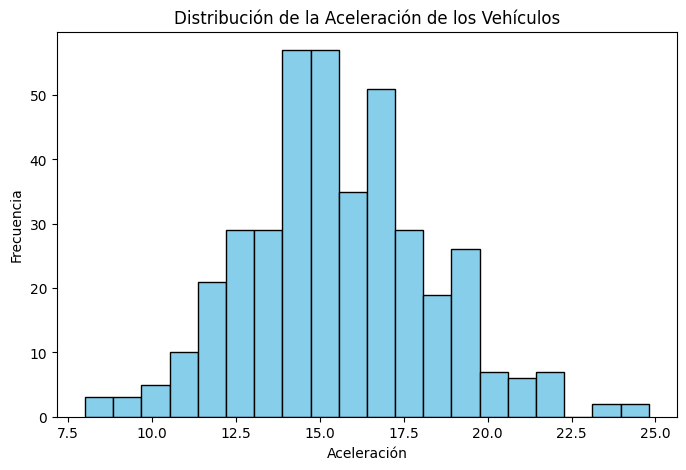

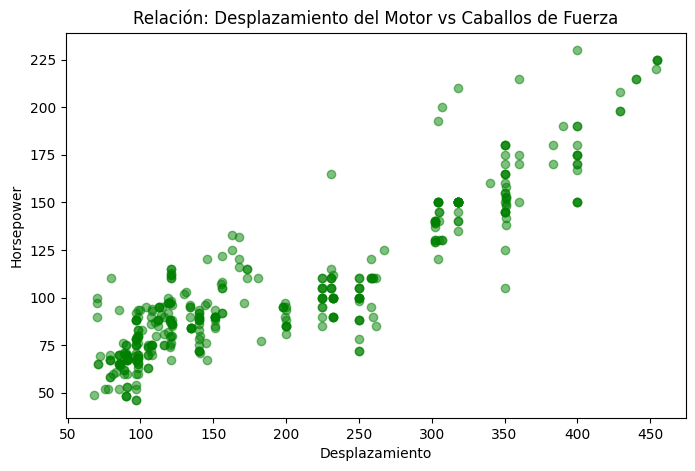

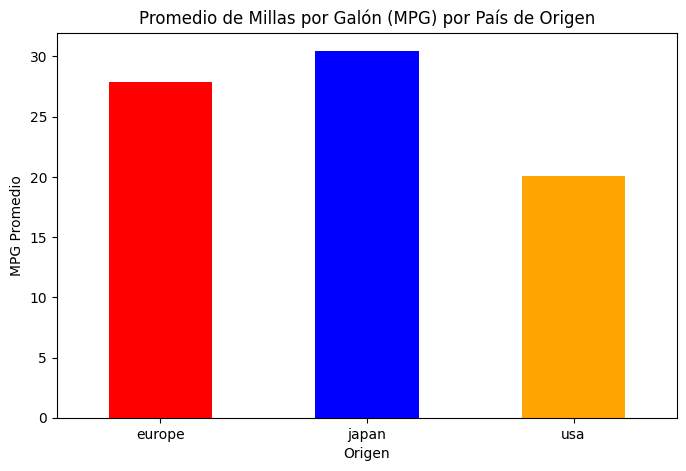

In [1]:
# Parte 1: Carga y Limpieza
# Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Lectura del archivo CSV desde la URL [1]
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"
df = pd.read_csv(url)

# Inspección de datos
print("Primeras 5 filas:")
print(df.head())
print("\nTipos de datos por columna:")
print(df.info())

# Tratamiento de valores nulos en 'horsepower'
# Nota: Se asegura que la columna sea numérica primero (info externa)
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')
mediana_hp = df['horsepower'].median()
df['horsepower'] = df['horsepower'].fillna(mediana_hp)

# Creación de nueva columna: relación peso/potencia
df['relacion_peso_potencia'] = df['weight'] / df['horsepower']
# 1. Histograma: Distribución de la aceleración
plt.figure(figsize=(8, 5))
plt.hist(df['acceleration'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribución de la Aceleración de los Vehículos')
plt.xlabel('Aceleración')
plt.ylabel('Frecuencia')
plt.show() # [1]

# 2. Gráfico de Dispersión: Desplazamiento vs Caballos de fuerza
plt.figure(figsize=(8, 5))
plt.scatter(df['displacement'], df['horsepower'], alpha=0.5, color='green')
plt.title('Relación: Desplazamiento del Motor vs Caballos de Fuerza')
plt.xlabel('Desplazamiento')
plt.ylabel('Horsepower')
plt.show() # [1]

# 3. Gráfico de Barras: Promedio de rendimiento (mpg) por origen
# Se agrupan los datos primero
df_grouped = df.groupby('origin')['mpg'].mean()
df_grouped.plot(kind='bar', color=['red', 'blue', 'orange'], figsize=(8, 5))
plt.title('Promedio de Millas por Galón (MPG) por País de Origen')
plt.xlabel('Origen')
plt.ylabel('MPG Promedio')
plt.xticks(rotation=0)
plt.show()